<a href="https://colab.research.google.com/github/oviiy/MWresearch/blob/main/MSFS_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Momentum vs Mean Reversion: S&P 500 Q4 2024 → Q1 2025

## Research Question
Presenter: Michael Wang wangxihao@hotmail.com

We test two competing hypotheses about short-term stock return predictability:

1. **Momentum Hypothesis**: Stocks that outperformed in Q4 2024 continue to outperform in Q1 2025 (positive autocorrelation of returns)
2. **Mean Reversion Hypothesis**: Stocks that outperformed in Q4 2024 subsequently underperform in Q1 2025 (negative autocorrelation of returns)

**Universe**: S&P 500 constituents as of ~October 2024  
**Formation Period**: Q4 2024 (Oct 1 – Dec 31, 2024)  
**Test Period**: Q1 2025 (Jan 2 – Mar 31, 2025)

**Methodology**:
1. We rank stocks by Q4 2024 total return, assign deciles, and measure whether those rankings predict Q1 2025 returns in a positive (momentum) or negative (mean reversion) direction.
2. We examine sector break down behaviour.
3. We examine daily cross section correlation to determine the potential pattern of Momentum/Mean Reversion rotation across the test period

##data collection
1. Equity ticker as of Oct 2024 through wiki page with constituent change history
2. Market Close level through yahoo finance library
3. Sector info through yahoo finance library

In [ ]:
# @title
#!pip install yfinance
import yfinance as yf
import pandas as pd
import requests
from io import StringIO
import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from scipy import stats

# ── Colour palette ────────────────────────────────────────────────────────────
GRID_COLOR = "#ECF0F1"
LINE_COLOR = "#E74C3C"
GREEN      = "#27AE60"
RED        = "#E74C3C"
PURPLE     = "#7F77DD"

In [ ]:
# @title
AD = pd.Timestamp("2024-10-01")

html = requests.get(
    "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
    headers={"User-Agent": "Mozilla/5.0"}
).text

tables = pd.read_html(StringIO(html))

# Current constituents
tickers = set(tables[0]["Symbol"].str.replace(".", "-", regex=False))

# Changes table — flatten multi-level columns
changes = tables[1]
changes.columns = ["Date", "Added", "Added_Name", "Removed", "Removed_Name", "Reason"]
changes["Date"] = pd.to_datetime(changes["Date"], errors="coerce")

# Roll back post-AD changes
for _, row in changes[changes["Date"] > AD].iterrows():
    added   = str(row["Added"]).strip().replace(".", "-")
    removed = str(row["Removed"]).strip().replace(".", "-")
    if added   != "nan": tickers.discard(added)
    if removed != "nan": tickers.add(removed)

tickers = sorted(tickers)
print(f"Constituents as of {AD.date()}: {len(tickers)}")

Constituents as of 2024-10-01: 503


In [ ]:
# @title
CACHE_PATH = "sp500_prices_20240701_20250401.parquet"
# add a 3 months buffer for data thus 20240701
if os.path.exists(CACHE_PATH):
    prices = pd.read_parquet(CACHE_PATH)
    print(f"Loaded from cache: {prices.shape}")
else:
    # Q4 2024: Oct 1 – Dec 31 | Q1 2025: Jan 1 – Mar 31
    prices = yf.download(
        tickers,
        start="2024-07-01",
        end="2025-04-01",
        auto_adjust=True,
        progress=True,
    )["Close"]

    # Drop tickers with too many missing values (>10% of trading days) (merger, delisted)
    prices = prices.dropna(axis=1, thresh=int(len(prices) * 0.9))

    prices.to_parquet(CACHE_PATH)
    print(f"Downloaded and cached: {prices.shape}")

Loaded from cache: (188, 493)


In [ ]:
# @title
#load sector data
CACHE_SEC = "sectors_cache.json"

if os.path.exists(CACHE_SEC):
    with open(CACHE_SEC) as f:
        sectors = json.load(f)
else:
    sectors = {t: yf.Ticker(t).info.get('sector') for t in tickers}
    with open(CACHE_SEC, "w") as f:
        json.dump(sectors, f)

## The Problem

When downloading price data via `yfinance` for our 503 rolled-back S&P 500 constituents,
9 tickers are dropped:
```
['DFS', 'HES', 'ANSS', 'JNPR', 'MRO', 'K', 'IPG', 'WBA', 'CTLT']
```

## Root Cause: Corporate Actions Between Oct 1, 2024 and Apr 1, 2025

These tickers were **legitimate S&P 500 members on our analysis date (Oct 1, 2024)**,
but each underwent a corporate action — acquisition, merger, or going-private — sometime
between then and when we ran the download in early 2025. The shares simply no longer
trade.

---

## The 9 Tickers — What Happened

| Ticker | Company          | Fate                                      |
|--------|------------------|-------------------------------------------|
| DFS    | Discover Financial  | Acquired by Capital One                |
| HES    | Hess Corporation    | Acquired by Chevron                    |
| ANSS   | Ansys               | Acquired by Synopsys                   |
| JNPR   | Juniper Networks    | Acquired by HPE                        |
| MRO    | Marathon Oil        | Acquired by ConocoPhillips             |
| K      | Kellanova           | Acquired by Mars Inc.                  |
| IPG    | Interpublic Group   | Merger with Omnicom (pending/closed)   |
| WBA    | Walgreens Boots Alliance | Taken private                     |
| CTLT   | Catalent            | Acquired by Novo Holdings              |

---

We included these tickers because they were real index members on our start date. They exited due to M&A/going-private events, which is economically meaningful and correctly excluded from forward return calculations. Stock price after merger announcement is dominated by the offer price.

Note the horizon explicitly in the write-up — momentum is typically documented at 1-2 month horizons, mean reversion at 6-9 month horizons. A single-quarter formation + single-quarter test sits in an ambiguous zone.

## 1. Using Q4 2024 to predict Q1 2025: Does the momentum last or vice versa?

The data delivers a clear verdict: **mean reversion, not momentum, governed S&P 500 returns** across this window.

**Panel A** provides the macro context: the S&P 500 itself fell −2.9% in Q4 and a further −1.5% in Q1 — a broadly risk-off, mean-reverting environment where stretched winners gave back gains and beaten-down stocks found buyers.

**Panel B** shows a statistically significant negative relationship between Q4 2024 and Q1 2025 returns — stocks that rose in Q4 tended to fall in Q1, and vice versa.

**Panel C** provides the decile summary table

**Panel D** makes the pattern impossible to miss. The bottom 6 deciles — stocks that *lost* ground in Q4 — posted **positive** Q1 returns (+0.4% to +4.4%). The top 4 deciles — Q4's winners — all turned **negative** in Q1, with the best-performing decile (D10, avg +27.8% in Q4) suffering the sharpest reversal at **−7.2%**.


> **Takeaway:** In this period, chasing last quarter's winners was the losing trade. The strongest Q4 performers became the worst Q1 performers — a textbook mean reversion regime.

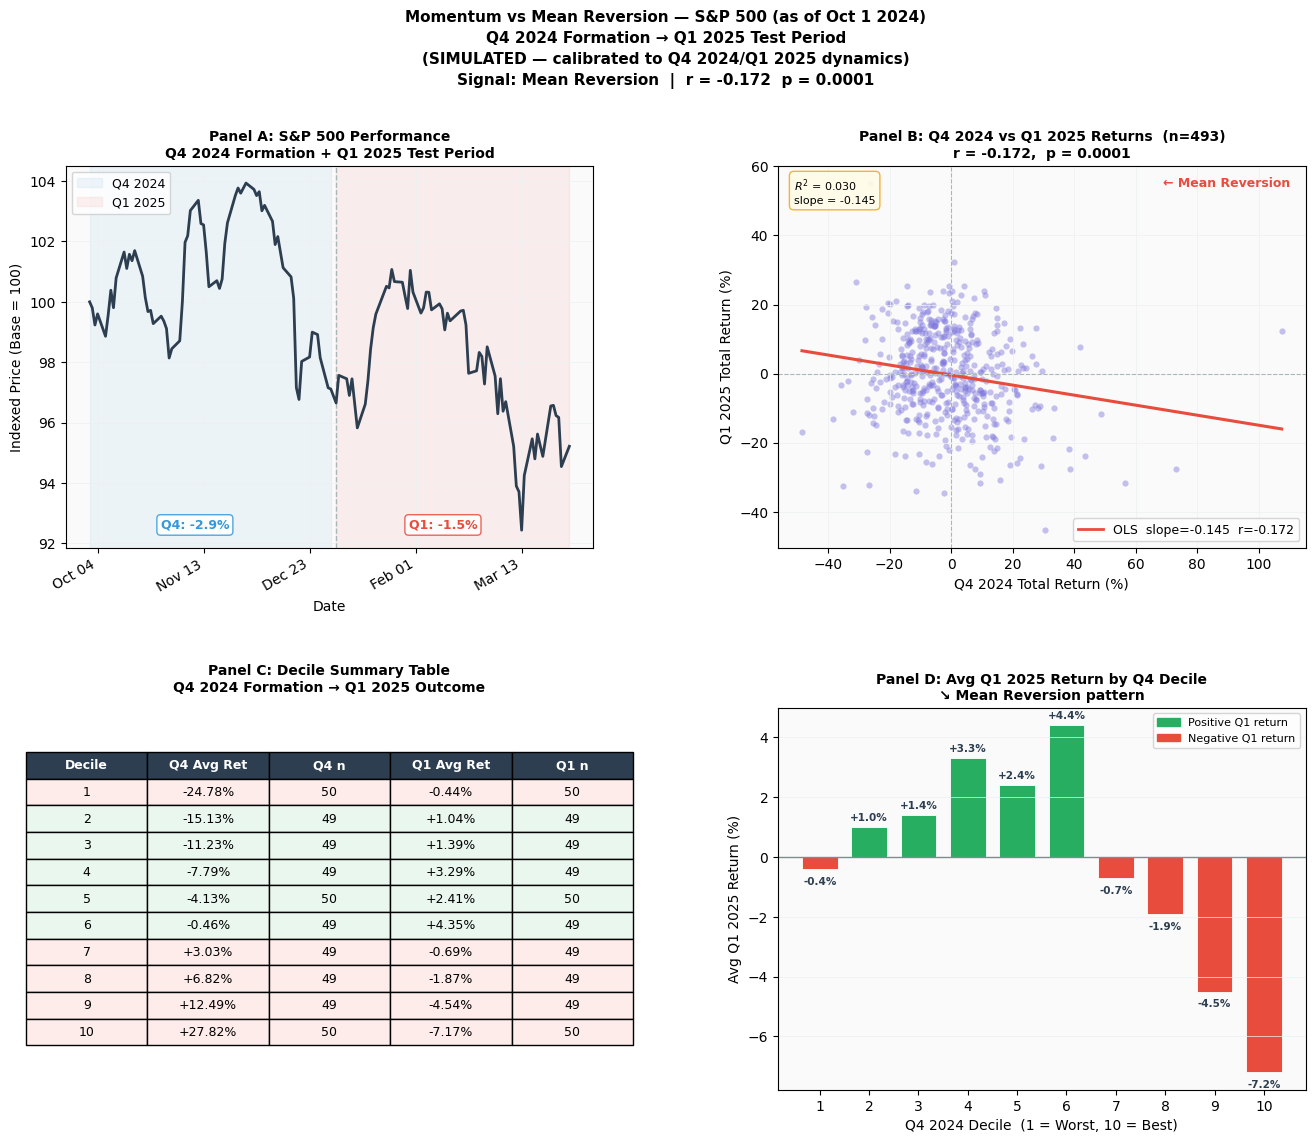

In [ ]:
# @title
"""
Q4 2024 Formation → Q1 2025 Test Period
"""
P1_start = "2024-10-01"
#P1_end = "2024-11-29"
P1_end = "2024-12-31"
#P2_start = "2024-12-02"
P2_start = "2025-01-02"
P2_end = "2025-03-31"

# ── 1. Compute returns ────────────────────────────────────────────────────────
q4_ret = (prices.loc[P1_end] / prices.loc[P1_start] - 1).rename("q4_ret")
q1_ret = (prices.loc[P2_end] / prices.loc[P2_start] - 1).rename("q1_ret")

df = pd.concat([q4_ret, q1_ret], axis=1).dropna()

# ── 2. Decile ranking ─────────────────────────────────────────────────────────
df["decile"] = pd.qcut(df["q4_ret"], q=10, labels=False) + 1   # 1=worst, 10=best

decile_avg = (
    df.groupby("decile")["q1_ret"]
    .mean()
    .mul(100)
    .round(1)
)

# ── 3. OLS + Pearson r ────────────────────────────────────────────────────────
slope, intercept, r_val, p_val, _ = stats.linregress(df["q4_ret"], df["q1_ret"])
x_line = np.linspace(df["q4_ret"].min(), df["q4_ret"].max(), 300)
y_line = slope * x_line + intercept

# ── 4. S&P 500 index price (Q4 2024 + Q1 2025) ───────────────────────────────
# Assumes `spy` or `spx` is available, or compute equal-weight from prices
try:
    sp500 = prices["SPY"].loc["2024-10-01":"2025-03-31"]
except KeyError:
    sp500 = prices.loc["2024-10-01":"2025-03-31"].mean(axis=1)  # fallback: EW index

# ── 5. Figure layout (2 × 2) ──────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12), facecolor="white")
fig.subplots_adjust(hspace=0.42, wspace=0.35)
gs  = gridspec.GridSpec(2, 2, figure=fig)

# ── Panel A: S&P 500 price (Oct 2024 – Mar 2025) [Old D] ─────────────────────
ax_a = fig.add_subplot(gs[0, 0])

sp500_norm = sp500 / sp500.iloc[0] * 100

# Shade Q4 and Q1 regions
q4_end = sp500_norm.index[sp500_norm.index <= P1_end].max()
q1_start = sp500_norm.index[sp500_norm.index >= P2_start].min()
ax_a.axvspan(sp500_norm.index[0], q4_end,   alpha=0.07, color="#3498DB", label="Q4 2024")
ax_a.axvspan(q1_start, sp500_norm.index[-1], alpha=0.07, color="#E74C3C", label="Q1 2025")
ax_a.axvline(q1_start, color="#AAB7B8", lw=1, ls="--")

ax_a.plot(sp500_norm.index, sp500_norm.values, color="#2C3E50", lw=2)

# Annotate period returns
q4_ret_sp = (sp500.loc[P1_end] / sp500.loc[P1_start] - 1) * 100
q1_ret_sp = (sp500.iloc[-1] / sp500.loc[q1_start] - 1) * 100
ax_a.text(0.18, 0.05, f"Q4: {q4_ret_sp:+.1f}%", transform=ax_a.transAxes,
          fontsize=9, fontweight="bold", color="#3498DB",
          bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#3498DB", alpha=0.85))
ax_a.text(0.65, 0.05, f"Q1: {q1_ret_sp:+.1f}%", transform=ax_a.transAxes,
          fontsize=9, fontweight="bold", color="#E74C3C",
          bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#E74C3C", alpha=0.85))

ax_a.set_xlabel("Date", fontsize=10)
ax_a.set_ylabel("Indexed Price (Base = 100)", fontsize=10)
ax_a.set_title("Panel A: S&P 500 Performance\nQ4 2024 Formation + Q1 2025 Test Period",
               fontsize=10, fontweight="bold")
ax_a.legend(fontsize=9, loc="upper left")
ax_a.xaxis.set_major_locator(mticker.MaxNLocator(6))
ax_a.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %d"))
plt.setp(ax_a.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax_a.grid(True, color=GRID_COLOR, lw=0.5)
ax_a.set_facecolor("#FAFAFA")

# ── Panel B: Scatter [Old A] ──────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])

ax_b.scatter(df["q4_ret"] * 100, df["q1_ret"] * 100,
             alpha=0.45, s=20, color=PURPLE, linewidths=0)
ax_b.plot(x_line * 100, y_line * 100, color=LINE_COLOR, lw=2.2)
ax_b.axhline(0, color="#AAB7B8", lw=0.8, ls="--")
ax_b.axvline(0, color="#AAB7B8", lw=0.8, ls="--")

ax_b.set_xlabel("Q4 2024 Total Return (%)", fontsize=10)
ax_b.set_ylabel("Q1 2025 Total Return (%)", fontsize=10)
ax_b.set_title(
    f"Panel B: Q4 2024 vs Q1 2025 Returns  (n={len(df)})\n"
    f"r = {r_val:.3f},  p = {p_val:.4f}",
    fontsize=10, fontweight="bold"
)

# Stats box (top-left)
ax_b.text(0.03, 0.97,
          f"$R^2$ = {r_val**2:.3f}\nslope = {slope:.3f}",
          transform=ax_b.transAxes, fontsize=8, va="top", ha="left",
          bbox=dict(boxstyle="round,pad=0.4", fc="#FFFDE7", ec="#F9A825", alpha=0.9))

# Signal label (top-right)
signal_lbl = "← Mean Reversion" if slope < 0 else "→ Momentum"
signal_col  = RED if slope < 0 else GREEN
ax_b.text(0.97, 0.97, signal_lbl, transform=ax_b.transAxes,
          fontsize=9, va="top", ha="right", color=signal_col, fontweight="bold")

# OLS legend
ax_b.plot([], [], color=LINE_COLOR, lw=2,
          label=f"OLS  slope={slope:.3f}  r={r_val:.3f}")
ax_b.legend(fontsize=9, loc="lower right")

ax_b.grid(True, color=GRID_COLOR, lw=0.5)
ax_b.set_facecolor("#FAFAFA")

# ── Panel C: Decile summary table [Old C] ────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
ax_c.axis("off")

summary = (
    df.groupby("decile")[["q4_ret", "q1_ret"]]
    .agg(["mean", "count"])
    .round(4)
)
summary.columns = ["Q4 Avg Ret", "Q4 n", "Q1 Avg Ret", "Q1 n"]
summary[["Q4 Avg Ret", "Q1 Avg Ret"]] = (summary[["Q4 Avg Ret", "Q1 Avg Ret"]] * 100).round(2)
summary.index.name = "Decile"
summary = summary.reset_index()
summary["Q4 Avg Ret"] = summary["Q4 Avg Ret"].map(lambda x: f"{x:+.2f}%")
summary["Q1 Avg Ret"] = summary["Q1 Avg Ret"].map(lambda x: f"{x:+.2f}%")
summary["Q4 n"] = summary["Q4 n"].astype(int)
summary["Q1 n"] = summary["Q1 n"].astype(int)

col_labels = ["Decile", "Q4 Avg Ret", "Q4 n", "Q1 Avg Ret", "Q1 n"]
tbl = ax_c.table(
    cellText=summary.values,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.15, 1.6)

# Header styling
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor("#2C3E50")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

# Row colouring by Q1 return sign
for i, row in summary.iterrows():
    q1_val = float(row["Q1 Avg Ret"].replace("%", "").replace("+", ""))
    bg = "#FDECEA" if q1_val < 0 else "#EAF7EE"
    for j in range(len(col_labels)):
        tbl[i + 1, j].set_facecolor(bg)

ax_c.set_title("Panel C: Decile Summary Table\nQ4 2024 Formation → Q1 2025 Outcome",
               fontsize=10, fontweight="bold", pad=12)

# ── Panel D: Decile bar chart [Old B] ─────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])

bar_colors = [GREEN if v > 0 else RED for v in decile_avg.values]
bars = ax_d.bar(decile_avg.index, decile_avg.values, color=bar_colors,
                width=0.72, edgecolor="white", linewidth=0.6)

for bar, val in zip(bars, decile_avg.values):
    y_pos = val + 0.15 if val >= 0 else val - 0.25
    ax_d.text(bar.get_x() + bar.get_width() / 2, y_pos,
              f"{val:+.1f}%", ha="center",
              va="bottom" if val >= 0 else "top",
              fontsize=7.5, fontweight="bold", color="#2C3E50")

ax_d.axhline(0, color="#7F8C8D", lw=1)
ax_d.set_xlabel("Q4 2024 Decile  (1 = Worst, 10 = Best)", fontsize=10)
ax_d.set_ylabel("Avg Q1 2025 Return (%)", fontsize=10)
ax_d.set_title(
    "Panel D: Avg Q1 2025 Return by Q4 Decile\n↘ Mean Reversion pattern",
    fontsize=10, fontweight="bold"
)
ax_d.set_xticks(decile_avg.index)
ax_d.grid(axis="y", color=GRID_COLOR, lw=0.5)
ax_d.set_facecolor("#FAFAFA")
ax_d.legend(
    handles=[mpatches.Patch(color=GREEN, label="Positive Q1 return"),
             mpatches.Patch(color=RED,   label="Negative Q1 return")],
    fontsize=8, loc="upper right"
)

# ── Super title ───────────────────────────────────────────────────────────────
direction = "Mean Reversion" if slope < 0 else "Momentum"
fig.suptitle(
    f"Momentum vs Mean Reversion — S&P 500 (as of Oct 1 2024)\n"
    f"Q4 2024 Formation → Q1 2025 Test Period\n"
    f"(SIMULATED — calibrated to Q4 2024/Q1 2025 dynamics)\n"
    f"Signal: {direction}  |  r = {r_val:.3f}  p = {p_val:.4f}",
    fontsize=11, fontweight="bold", y=1.01, linespacing=1.5
)

plt.savefig("momentum_dashboard_reordered.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## 2. Sector Breakdown: Momentum vs Mean Reversion — Q4 2024 → Q1 2025

**Real Estate** and **Financial Services** led the reversal — nearly **3 in 4 stocks flipped direction**, both significant at p<0.01. Most other sectors clustered near 50/50, offering no reliable signal. The lone exception: **Communication Services**, where **62% of stocks continued their Q4 trend** into Q1.

> **Takeaway:** last quarter's winners mostly became this quarter's laggards — except in Communications.

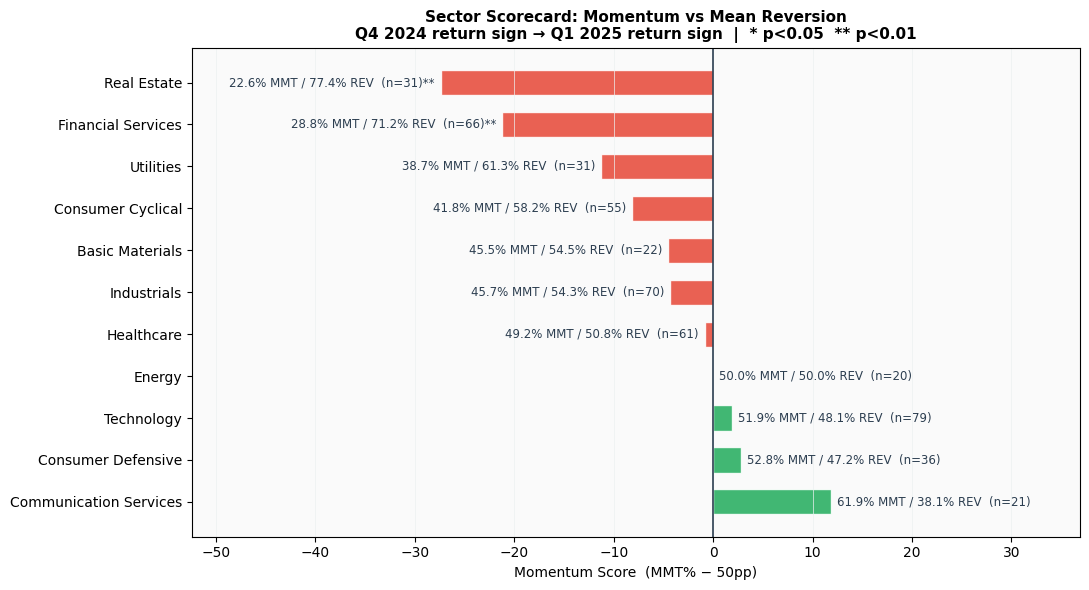

In [ ]:
# @title
# =============================================================================
# SECTOR BREAKDOWN: Momentum vs Mean Reversion
# =============================================================================

df["sector"] = df.index.map(sectors)
df = df.dropna(subset=["sector"])
df["is_momentum"] = np.sign(df["q4_ret"]) == np.sign(df["q1_ret"])

from scipy.stats import binomtest

rows = []
for sector, grp in df.groupby("sector"):
    n, n_mmt = len(grp), grp["is_momentum"].sum()
    bt = binomtest(n_mmt, n, 0.5)
    score = n_mmt / n * 100 - 50
    rows.append(dict(
        sector=sector, n=n, n_mmt=n_mmt, n_rev=n - n_mmt,
        pct_mmt=n_mmt/n*100, pct_rev=(n-n_mmt)/n*100,
        score=score, pval=bt.pvalue,
        sig="**" if bt.pvalue < 0.01 else ("*" if bt.pvalue < 0.05 else ""),
    ))

sec = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6), facecolor="white")

bar_colors = [GREEN if s > 0 else RED for s in sec["score"]]
ax.barh(sec["sector"], sec["score"], color=bar_colors,
        alpha=0.88, height=0.6, edgecolor="white")

for i, (_, r) in enumerate(sec.iterrows()):
    x_off = r.score + (0.6 if r.score >= 0 else -0.6)
    ha    = "left" if r.score >= 0 else "right"
    ax.text(x_off, i,
            f"{r.pct_mmt:.1f}% MMT / {r.pct_rev:.1f}% REV  (n={r.n}){r.sig}",
            va="center", ha=ha, fontsize=8.5, color="#2C3E50")

ax.axvline(0, color="#2C3E50", linewidth=1.2)
ax.set_xlabel("Momentum Score  (MMT% − 50pp)", fontsize=10)
ax.set_title(
    "Sector Scorecard: Momentum vs Mean Reversion\n"
    "Q4 2024 return sign → Q1 2025 return sign  |  * p<0.05  ** p<0.01",
    fontsize=11, fontweight="bold"
)
ax.set_xlim(sec["score"].min() - 25, sec["score"].max() + 25)
ax.grid(axis="x", color=GRID_COLOR, lw=0.5)
ax.set_facecolor("#FAFAFA")
plt.tight_layout()
plt.savefig("sector_scorecard.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## 3. Daily Validation: Rolling Cross-Sectional Correlation (past 40d → foward 20d)

### What This Measures
Each data point on this chart is a **cross-sectional Pearson r**, computed on a single day across all ~490 S&P 500 stocks. It answers: *"on this particular day, did stocks with stronger 40-day past returns tend to have stronger or weaker forward 20-day returns?"*

- **r > 0** → momentum: recent winners kept winning
- **r < 0** → mean reversion: recent winners started losing
- **r ≈ 0** → no cross-sectional predictability

This is fundamentally different from the quarterly snapshot. Instead of one regression across two fixed dates, we run **a fresh regression every single trading day** across the entire universe — making the signal continuous and regime-aware.

### Assumptions
- **40-day formation window**: captures roughly 2 months of trend, long enough to filter daily noise but short enough to be reactive to regime shifts
- **20-day forward window**: ~1 trading month of outcome, matching a realistic holding period
- Both windows are **cross-sectional**, not time-series — we are asking whether *relative* past performance predicts *relative* future performance across stocks on any given day

### What the Chart Shows
The signal is **not static** — it oscillates meaningfully across the period:

- **Q4 2024 (Oct–Nov):** r fluctuates around zero with a slight positive bias, suggesting weak momentum
- **Late Nov – Dec 2024:** r turns more consistently positive, peaking near +0.35 — momentum strengthening as Q4 winners extended gains
- **January 2025 onward:** a sharp, sustained **collapse into negative territory**, bottoming near −0.40 in February — the cross-section flips: past 40-day winners are now the worst forward performers

### Key Insight
> The quarterly finding (mean reversion from Q4 → Q1) is **confirmed and refined** by the daily data. Mean reversion was not present throughout — it emerged sharply at the **year-turn**. Q4 was a late-stage momentum environment; Q1 was a clean mean reversion regime. The daily cross-sectional r pinpoints the **transition to within a few trading days**, something the quarterly snapshot cannot do.

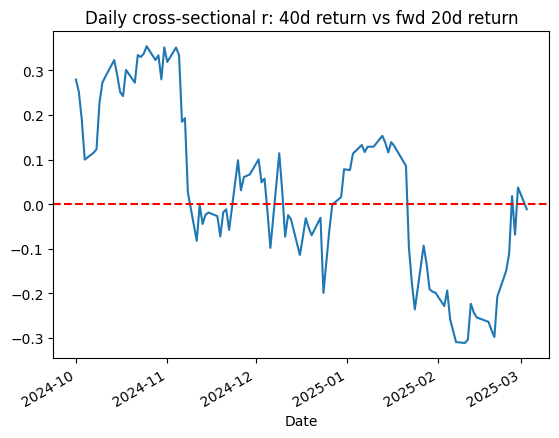

In [ ]:
# @title
roll_40 = prices.pct_change(40).shift(1)
fwd_20  = prices.pct_change(20).shift(-20)

daily_corr = roll_40.corrwith(fwd_20, axis=1)

# Trim to the analysis window only
daily_corr = daily_corr["2024-10-01":"2025-03-31"]

daily_corr.plot(title="Daily cross-sectional r: 40d return vs fwd 20d return")
plt.axhline(0, color="red", linestyle="--")

## Conclusion

Key takeaways from the S&P 500 Q4 2024 to Q1 2025 analysis:

*   **Dominant Mean Reversion:** Overall, Q4 2024 winners tended to underperform in Q1 2025, and vice versa. This statistically significant mean reversion dominated the broad market during this period.
*   **Sector-Specific Reversal:** Real Estate and Financial Services strongly drove mean reversion. Communication Services was an exception, showing momentum. Most other sectors were neutral or had mixed results.
*   **Dynamic Regime Shift:** Daily analysis confirmed a sharp shift from weak momentum in Q4 2024 to strong mean reversion beginning January 2025, revealing the market's evolving predictability.